In [12]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20, 'figure.figsize': (8, 4)})

%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import seaborn as sns
sns.set()

In [14]:
df = pd.read_csv("supermarket_sales.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     1000 non-null   object 
 1   Branch         1000 non-null   object 
 2   City           1000 non-null   object 
 3   Customer type  1000 non-null   object 
 4   Gender         1000 non-null   object 
 5   Product line   1000 non-null   object 
 6   Unit price     1000 non-null   float64
 7   Quantity       1000 non-null   int64  
 8   Tax 5%         1000 non-null   float64
 9   Total          1000 non-null   float64
 10  Date           1000 non-null   object 
 11  Time           1000 non-null   object 
 12  Payment        1000 non-null   object 
 13  Rating         1000 non-null   float64
dtypes: float64(4), int64(1), object(9)
memory usage: 109.5+ KB


#### Question 1: Example

In [17]:
### how many purchases (rows in the table, not 'Quantity') were done by Male and Female customers?

#### Question 1 - solution: Example

In [20]:
"""
Counts the number of men and women in the columns and creates a new table with the data.
"""

m_amount = len(df[df['Gender'] == 'Male'])
f_amount = len(df[df['Gender'] == 'Female'])

# do not print any intermediate results
# print *only your final* result in the form of a data frame (for clarity)

result = [('purchases by male', m_amount), ('purchases by female', f_amount)]
pd.DataFrame(result)

,0,1
0,purchases by male,498
1,purchases by female,502


#### Question 2

In [23]:
### what is the average Rating for products in the "Home and lifestyle" Product line?

In [25]:
"""
Calculates the average review of products in the category "Home and lifestyle".
"""

df[df['Product line'] == 'Home and lifestyle']['Rating'].mean()

6.8375

#### Question 3

In [28]:
### how many products in each Product line were sold during the first week (days 1-7 including) of February 2019?
### use the 'Quantity' column for that purpose - the number of products purchased

In [30]:
"""
Sorts the dates.
Calculates the sum of orders by category.
"""

filtered_df = df[(df['Date'] >= '01/02/2019') & (df['Date'] <= '07/02/2019')]
total_orders_by_product_line = filtered_df.groupby('Product line')['Quantity'].sum()
pd.DataFrame(total_orders_by_product_line)

,Quantity
Product line,
Electronic accessories,331
Fashion accessories,380
Food and beverages,409
Health and beauty,344
Home and lifestyle,455
Sports and travel,345


#### Question 4

In [33]:
### plot a bar chart showing the number of products per category computed in the previous question

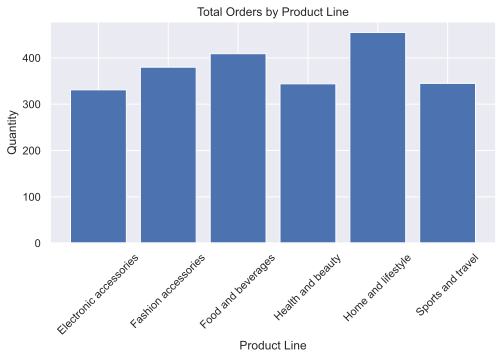

In [69]:
"""
Creates a bar plot of quantity versus product category.
"""

plt.bar(total_orders_by_product_line.index, total_orders_by_product_line.values)

plt.xticks(rotation=45)
plt.title("Total Orders by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Quantity")
plt.show()

#### Question 5

In [ ]:
### plot the same bar chart as above - split by gender (male, female)
### the split bar chart is called stacked bar: look up "plot stacked bar charts from a dataframe" to see how to plot it

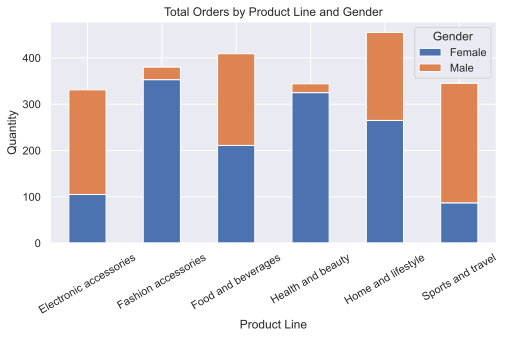

In [73]:
"""
Creates a bar plot of quantity versus product category and divides the columns by men and women separately.
"""

grouped = filtered_df.groupby(['Product line', 'Gender'])['Quantity'].sum().unstack()
grouped.plot(kind='bar', stacked=True)
plt.title('Total Orders by Product Line and Gender')
plt.xlabel('Product Line')
plt.ylabel('Quantity')
plt.xticks(rotation=30)
plt.legend(title='Gender')
plt.show()


#### Question 6

In [ ]:
### what is the total sales ('Total') done by each Payment type during the whole period?
### use the full data in the dataset (not the first week of March) from now on

In [71]:
"""
Calculates the total sales amount for each payment method used in the dataset.
It groups the data by the 'Payment' type and sums the 'Total' sales for each group.
"""

df.groupby('Payment')['Total'].sum().reset_index()

,Payment,Total
0,Cash,112206.570
1,Credit card,100767.072
2,Ewallet,109993.107


#### Question 7

In [39]:
### plot a chart with total sales ('Total') of the "Sports and travel" products by calendar week (Monday-Sunday): 
### note the first and the last week can be incomplete (for instance, the data starts on Wednesday, and ends on Friday)
### assume all our sales data spans the same year (for instance, 2019)

### you can make use of the isocalendar() function: https://www.geeksforgeeks.org/isocalendar-function-of-datetime-date-class-in-python/

### x axis are weeks enumerated from the first to the last calendar week in the data
### y axis is the total sales that week

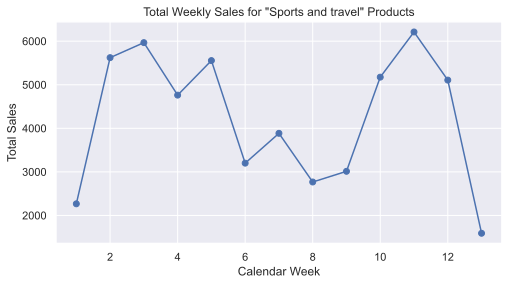

In [41]:
"""
Filters sales data for the "Sports and travel" product line and calculates total weekly sales.
It then plots these totals on a line graph, showing how sales change across calendar weeks.
"""

sports_df = df[df['Product line'] == 'Sports and travel'].copy()
sports_df['Date'] = pd.to_datetime(sports_df['Date'])
sports_df['Week'] = sports_df['Date'].dt.isocalendar().week
weekly_sales = sports_df.groupby('Week')['Total'].sum().reset_index()

plt.plot(weekly_sales['Week'], weekly_sales['Total'], marker='o')
plt.title('Total Weekly Sales for "Sports and travel" Products')
plt.xlabel('Calendar Week')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

#### Question 8

In [43]:
### plot a line chart of total sales ('Total') per hour in our dataset
### the x axis will be an hour (e.g., 9, 10, 11), and the y axis will be the total amout of sales during that hour
### (e.g., for 9 - all sales between 09:00 and 10:00)

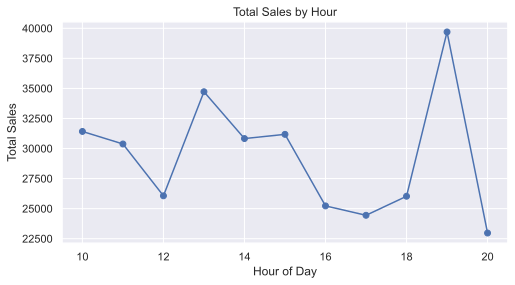

In [46]:
"""
Creates a new datetime column by combining the date and time, then extracts the hour of each sale.
It calculates total sales for each hour of the day and visualizes the results in a line plot.
"""

new_df = df
new_df['DateTime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])
new_df['Hour'] = new_df['DateTime'].dt.hour
hourly_sales = new_df.groupby('Hour')['Total'].sum().reset_index()

plt.plot(hourly_sales['Hour'], hourly_sales['Total'], marker='o')
plt.title('Total Sales by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

#### Question 9

In [49]:
### plot a line chart of the total number of purchases (rows) per hour in our dataset
### the x axis will be an hour (e.g., 9, 10, 11), and the y axis will be the total number of purchases during that hour
### (e.g., for 9 - all sales between 09:00 and 10:00)

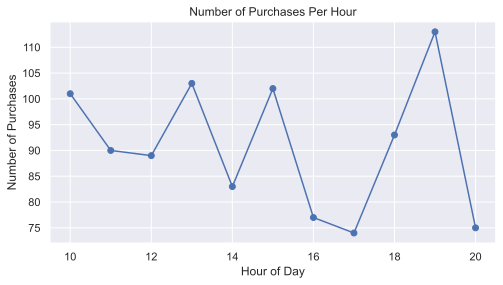

In [51]:
"""
Counts how many purchases were made during each hour of the day.
It then plots the number of purchases per hour in a line graph.
"""

hourly_counts = new_df['Hour'].value_counts().sort_index()

plt.plot(hourly_counts.index, hourly_counts.values, marker='o', linestyle='-')

plt.title('Number of Purchases Per Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Purchases')
plt.grid(True)
plt.show()

#### Question 10

In [54]:
### what is the total income of strategic products by City?

### for each non-strategic product (as detailed in the product_types_strategy.csv file), 
###    display break down of total sales by cities - a table with three columns: 
###    (1) product line, (2) city and (3) total sales (the "Total" column) for that line in the city

In [56]:
"""
Loads a csv file with product strategy info and filters out non-strategic product types.
It then summarizes total sales by product line and city, showing only those that match the non-strategic products.
"""

strategy_df = pd.read_csv('product_types_strategy.csv')
filtered_products = strategy_df[strategy_df['strategic'] == 'no']['Product type']
sales_summary = df.groupby(['Product line', 'City'])['Total'].sum().reset_index()
sales_summary = sales_summary[sales_summary['Product line'].isin(filtered_products)]

pd.DataFrame(sales_summary)

,Product line,City,Total
3,Fashion accessories,Mandalay,16413.3165
4,Fashion accessories,Naypyitaw,21560.0700
5,Fashion accessories,Yangon,16332.5085
12,Home and lifestyle,Mandalay,17549.1645
13,Home and lifestyle,Naypyitaw,13895.5530
14,Home and lifestyle,Yangon,22417.1955
